In [29]:
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
import uproot
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from utils import *
from convert_to_grpah import *
from torch_geometric.utils import to_networkx
import networkx as nx

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Data loading

In [2]:
ES_ROOT  = "/home/yujin/projects/wind/WIND_bkg_rejection/ROOT_FILEs/WIND_66_4in_40p_ES_10k_internal_PMT.ntuple.root"
# 16N_ROOT = "/home/yujin/projects/wind/BKG_rejection/dataset/WIND_66_4in_40p_16N_10k_internal.ntuple.root"

# ==== Parameters ====
ENERGY_CUT = 0 # MeV
VERTEX_CUT = 0 # mm
MIN_UNIQUE_PMTS = 4

es_data = event_selection(root_file=ES_FILE,
                          label=1,
                          energy_thr=ENERGY_CUT,
                          vtx_cut_mm=VERTEX_CUT, 
                          min_unique_pmt=MIN_UNIQUE_PMTS)

[Event Selection] Load from: /home/yujin/projects/wind/WIND_bkg_rejection/ROOT_FILEs/WIND_66_4in_40p_ES_10k_internal_PMT.ntuple.root
 - Total number of event in the root file : 10000
 - Energy cut: thr=0 MeV, criteria=total
     Input E  : Kinetic energy
     Selected : 9999 / 10000 (99.99%)
 - Vertex cut (Cylinder): Wall margin = 0 mm
     Fiducial R/Z    : R < 3000.0 mm, |Z| < 3000.0 mm
     Fiducial Volume : 169.646 m^3
     Fiducial Mass   : 169.646 tons (as Water)
     Selected        : 10000 / 10000 (100.00%)
 - 8171 ES event is selected


In [3]:
es_data

<Array [{mcPEx: [...], mcPEy: [...], ...}, ...] type='8171 * {mcPEx: var * ...'>

In [4]:
mcid = es_data["mcid"]
mcid

<Array [0, 1, 2, 3, 4, ..., 9993, 9994, 9997, 9998, 9999] type='8171 * int32'>

In [5]:
inx = 3
event = es_data[inx]
event

<Record {mcPEx: [...], mcPEy: [...], ...} type='{mcPEx: var * float64, mcPE...'>

In [6]:
# 1D jagged array
x_pos = event["mcPEx"]
y_pos = event["mcPEy"]
z_pos = event["mcPEz"]
charge = event["mcPECharge"]
hit_time = event["mcPEHitTime"]
x_pos

<Array [2.26e+03, 2.26e+03, 1.32e+03, ..., 375, 780, -450] type='118 * float64'>

# 2. Graph Nodes

In [7]:
pos, dirs, type = get_full_pmt_geometry()

In [8]:
idx = 9000
print(pos[idx])
print(dirs[idx])
print(type[idx])

[ 2576.47852195 -1363.44542462  -938.5       ]
[-0.88386913  0.46773428  0.        ]
2


In [18]:
pos_cyl = cartesian_to_cylindrical(pos)
print(pos_cyl[idx])

[2915.            5.79645968 -938.5       ]


# 3. Edges

In [10]:
edges = build_fixed_edge_index(pos_cyl, k=6)

In [11]:
edges

tensor([[   0,    0,    0,  ..., 9479, 9479, 9479],
        [   0,  180,  581,  ..., 1539, 1526,  934]])

In [12]:
test_node = 0  # 0번 PMT를 검사
neighbors = edges[1][edges[0] == test_node].tolist()

print(f"[{test_node}번 PMT의 연결 리스트]")
print(f"연결된 노드 번호들: {neighbors}")
print(f"연결 개수: {len(neighbors)}")

# 만약 자기 자신이 포함되어 있는지 궁금하다면
if test_node in neighbors:
    print(f"확인: 자기 자신({test_node})이 이웃에 포함되어 있습니다. (Self-loop)")

[0번 PMT의 연결 리스트]
연결된 노드 번호들: [0, 180, 581, 290, 60, 86, 451]
연결 개수: 7
확인: 자기 자신(0)이 이웃에 포함되어 있습니다. (Self-loop)


In [13]:
source_node_id = 100
mask = (edges[0] == source_node_id) # 첫 번째 줄이 100인 곳을 찾음
neighbors = edges[1][mask]          # 그 위치의 두 번째 줄(target) 값을 가져옴

print(f"PMT {source_node_id}에 연결된 이웃들: {neighbors.tolist()}")

PMT 100에 연결된 이웃들: [100, 51, 159, 226, 299, 376, 457]


# 4. Grpah

In [15]:
data = event_selection(root_file=ES_ROOT,
                       label=1,
                       energy_thr=0,
                       vtx_cut_mm=0,
                       min_unique_pmt=4)

[Event Selection] Load from: /home/yujin/projects/wind/WIND_bkg_rejection/ROOT_FILEs/WIND_66_4in_40p_ES_10k_internal_PMT.ntuple.root
 - Total number of event in the root file : 10000
 - Energy cut: thr=0 MeV, criteria=total
     Input E  : Kinetic energy
     Selected : 9999 / 10000 (99.99%)
 - Vertex cut (Cylinder): Wall margin = 0 mm
     Fiducial R/Z    : R < 3000.0 mm, |Z| < 3000.0 mm
     Fiducial Volume : 169.646 m^3
     Fiducial Mass   : 169.646 tons (as Water)
     Selected        : 10000 / 10000 (100.00%)
 - 8171 ES event is selected


In [16]:
pmt_lookup = get_pmt_id_map(pos)

In [20]:
graphs = process_data_to_graphs(data, pmt_lookup, pos_cyl, edges, 1)

# 5. Vis

In [27]:
def visualize_single_event_graph(data, event_idx=0, charge_threshold=0.5):
    """
    선택된 이벤트 그래프에서 신호가 있는 PMT들만 골라 시각화합니다.
    (9000개 다 그리면 안 보임)
    """
    print(f"\n[Visualization] Visualizing Event {event_idx}...")
    
    # 1. PyG Data 객체를 NetworkX 그래프로 변환
    # (to_networkx는 기본적으로 방향성이 있는 DiGraph를 만듭니다.)
    G = to_networkx(data, to_undirected=False)
    
    # 2. 노드 특징(Q) 로드
    charge = data.x[:, 0].numpy() # [9500, 1] -> [9500]
    
    # 3. 시각화할 노드 필터링: Charge가 기준치 이상인 것만
    # np.log10(q+1)을 했으므로 0보다 큰 값들이 신호가 있는 곳입니다.
    hit_node_mask = charge > charge_threshold
    # mask = charge > 0.0 # 모든 히트 PMT 표시
    
    selected_nodes = torch.arange(data.num_nodes)[hit_node_mask].tolist()
    
    if not selected_nodes:
        print(" - No nodes selected. Threshold is too high or the event is empty.")
        return

    # 4. 선택된 노드들만 포함하는 서브그래프(Subgraph) 생성
    subG = G.subgraph(selected_nodes)
    
    # 5. 레이아웃 결정 (노드의 기하학적 배치)
    # PMT의 좌표(r, phi, z) 중 시각적으로 보기 편한 것을 골라 평면에 배치합니다.
    # 여기서는 r, phi 좌표를 이용해 위에서 내려다본(Top-down) 뷰를 만듭니다.
    r, phi = data.x[selected_nodes, 2].numpy(), data.x[selected_nodes, 3].numpy()
    pos = {n: (r[i] * np.cos(phi[i]), r[i] * np.sin(phi[i])) for i, n in enumerate(selected_nodes)}

    # 6. 그리기 속성 설정
    node_size = charge[selected_nodes] * 100 # 신호가 강할수록 큰 점
    edge_color = 'gray'
    
    plt.figure(figsize=(10, 10))
    nx.draw_networkx(subG, pos=pos, 
                     node_size=node_size, 
                     node_color=charge[selected_nodes], # 신호가 강할수록 색이 진해짐
                     cmap=plt.cm.viridis,
                     with_labels=False, 
                     edge_color=edge_color,
                     alpha=0.6)
    
    plt.title(f"Graph of Selected Nodes (Q > {charge_threshold}) in Event {event_idx}")
    plt.axis('off')
    plt.show()


[Visualization] Visualizing Event 0...


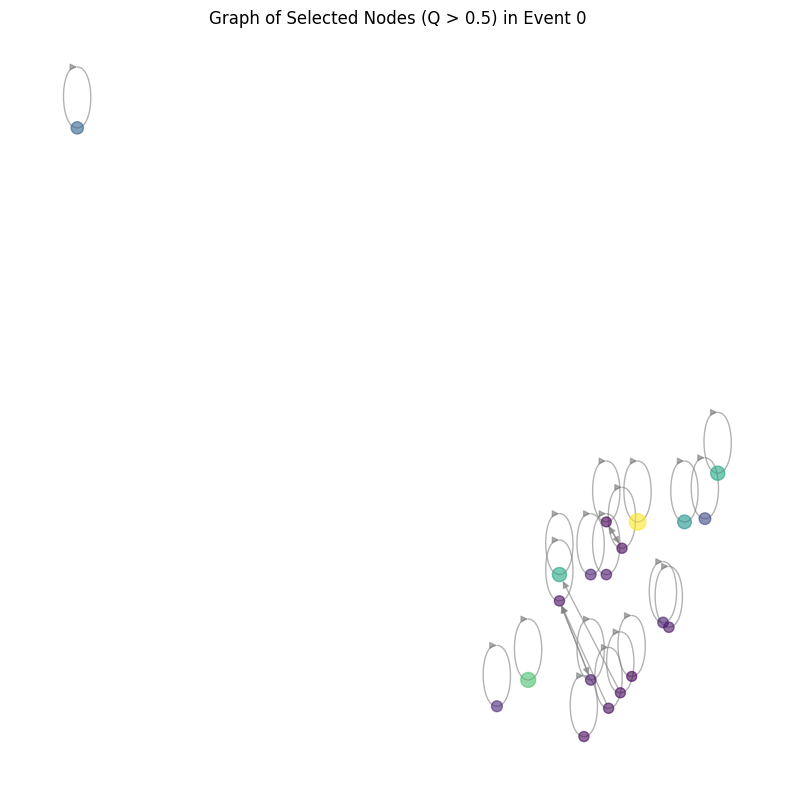

In [30]:
if 'graphs' in locals() and graphs:
    # 첫 번째 이벤트 그래프를 시각화합니다.
    visualize_single_event_graph(graphs[0], event_idx=0)
else:
    print("No graph data to visualize. Please generate 'graphs' list first.")